<a href="https://colab.research.google.com/github/glorenz1/MSE_Spring_2026/blob/main/Homework_2_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 2 for the MSE510/420 Course
- Instructor Sergei V. Kalinin, sergei2@utk.edu
- Please provide your name in the beginning of the notebook
- To submit the homework, please share it with my gmail address (available on Canvas)


Problem 1: Making function
- define an (arbitrary) scalar function  
- plot a graph over a chosen range
- create an array of sampled points (e.g. 7)
- show the points on the graph

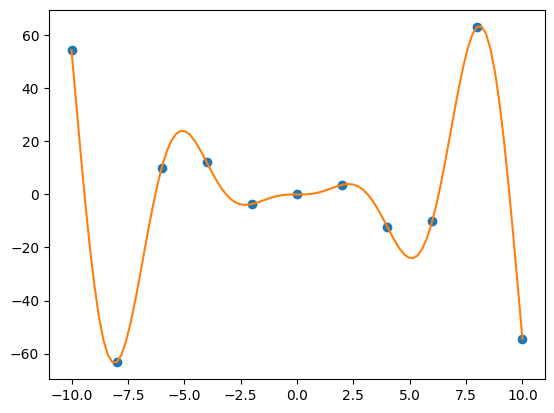

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.interpolate import CubicSpline


def f(x):
    return x**2 * np.sin(x)

xdat = np.linspace(-10,10,11)
fdat = f(xdat)

xref = np.linspace(-10,10,100)
fref = f(xref)

plt.plot(xdat,fdat,'o')
plt.plot(xref,fref)

Problem 2: Spline interpolation
- Interpolate the function using spline method
- Plot the difference between original and interpolated function
- Differentiate the function (analytically or numerically)
- Differentiate the interpolated function
- Compare the results

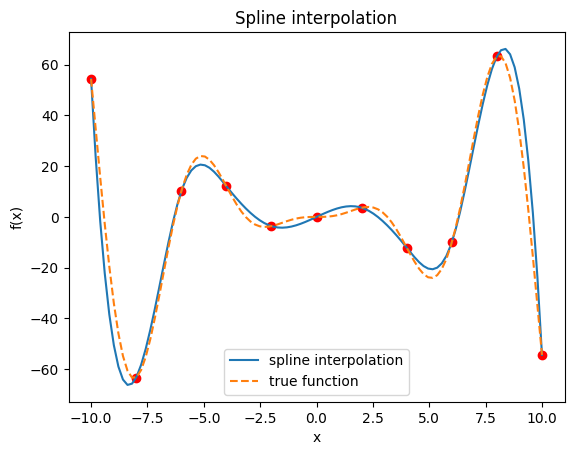

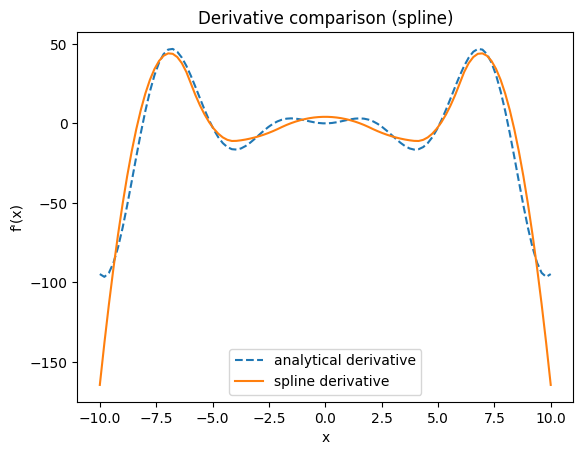

In [ ]:

spline_sine = CubicSpline(xdat,fdat)
xref = np.linspace(-10,10,100)
fref = f(xref)

fspline = spline_sine(xref)

plt.title("Spline interpolation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(xdat,fdat,'or')
plt.plot(xref,fspline,label='spline interpolation')
plt.plot(xref,fref,'--',label='true function')
plt.legend()
plt.show()

f_deriv_true = 2*xref*np.sin(xref) + xref**2 * np.cos(xref)  # analytical derivative
f_deriv_spline = spline_sine(xref, 1)                          # spline first derivative

plt.figure()
plt.title("Derivative comparison (spline)")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.plot(xref, f_deriv_true, '--', label='analytical derivative')
plt.plot(xref, f_deriv_spline, label='spline derivative')
plt.legend()
plt.show()

Problem 3: Linear interpolation
- Interpolate the function using linear method
- Plot the difference between original and interpolated function
- Differentiate the function (analytically or numerically)
- Differentiate the interpolated function
- Compare the results

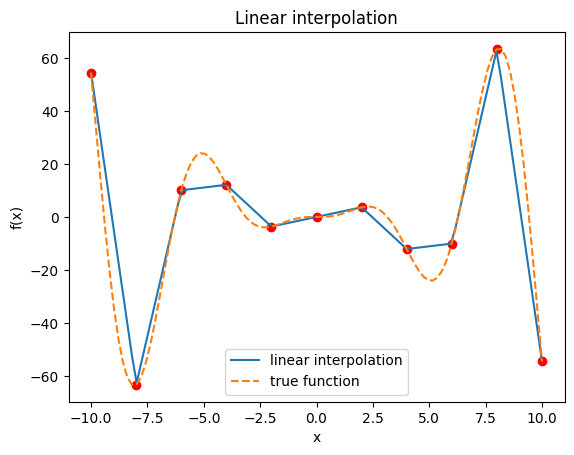

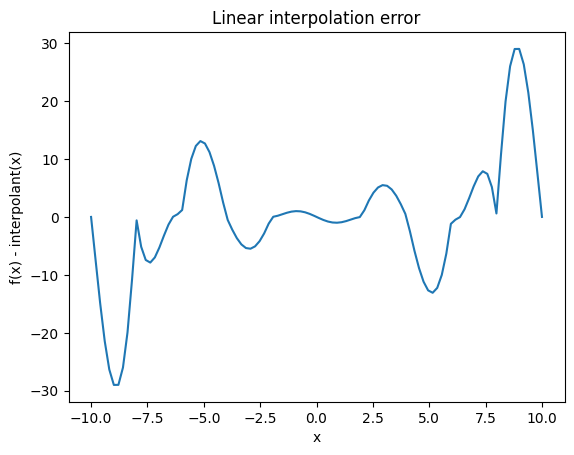

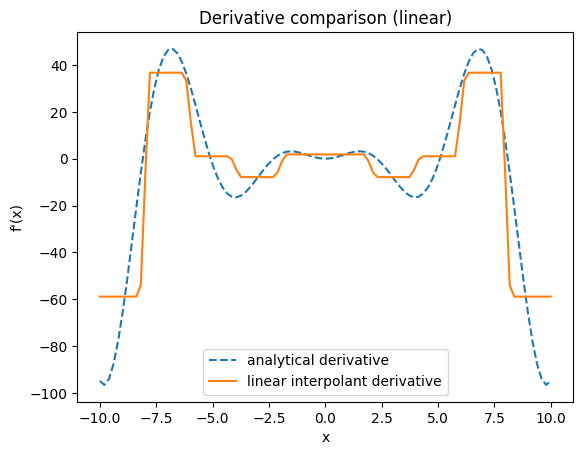

In [ ]:
def linear_int(x,x0,f0,x1,f1):
    return f0 + (f1 - f0) * (x-x0) / (x1-x0)


def f_linear_int(x, xdata, fdata):
    ind = np.searchsorted(xdata, x) # Search the right interval for point x
    if (ind == 0):
        if ((xdata[0] - x) > 1e-12):
            print("x = ", x, " is outside the interpolation range [",xdata[0],",",xdata[-1],"]")
        ind = ind + 1
    if (ind == len(xdata)):
        if ((x - xdata[-1]) > 1e-12):
            print("x = ", x, " is outside the interpolation range [",xdata[0],",",xdata[-1],"]")
        ind = ind - 1
    x0,f0 = xdata[ind-1],fdata[ind-1]
    x1,f1 = xdata[ind],fdata[ind]
    return linear_int(x,x0,f0,x1,f1)

# Calculate the values of f(x) using the linear interpolation
xcalc = np.linspace(-10,10,100)
fcalc = [f_linear_int(xin,xdat,fdat) for xin in xcalc]

plt.title("Linear interpolation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(xdat,fdat,'or')
plt.plot(xcalc,fcalc,label='linear interpolation')
plt.plot(xref,fref,'--',label='true function')
plt.legend()
plt.show()

# Difference plot
plt.figure()
plt.title("Linear interpolation error")
plt.xlabel("x")
plt.ylabel("f(x) - interpolant(x)")
plt.plot(xcalc, fref - fcalc)
plt.show()

dx = xcalc[1] - xcalc[0]
f_deriv_linear = np.gradient(fcalc, dx)
f_deriv_true = 2*xcalc*np.sin(xcalc) + xcalc**2 * np.cos(xcalc)

plt.figure()
plt.title("Derivative comparison (linear)")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.plot(xcalc, f_deriv_true, '--', label='analytical derivative')
plt.plot(xcalc, f_deriv_linear, label='linear interpolant derivative')
plt.legend()
plt.show()

Problem 4: Lagrange polynomial interpolation
- Interpolate the function using Lagrange polynomial method
- Plot the difference between original and interpolated function
- Differentiate the function (analytically or numerically)
- Differentiate the interpolated function
- Compare the results

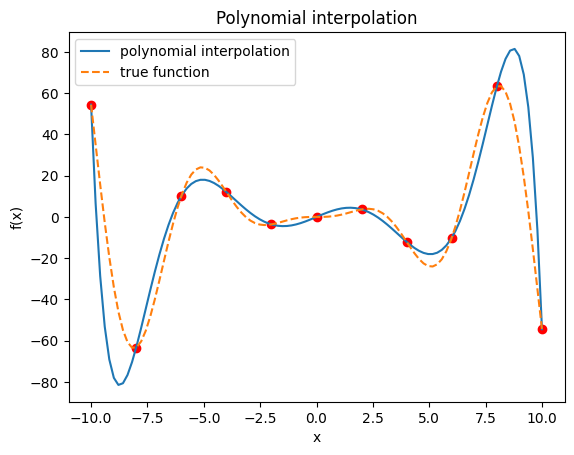

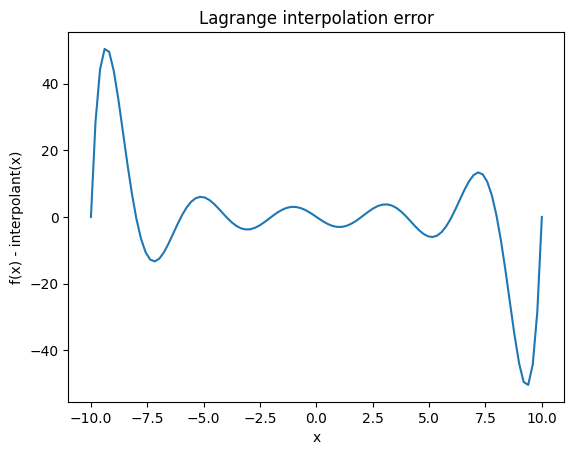

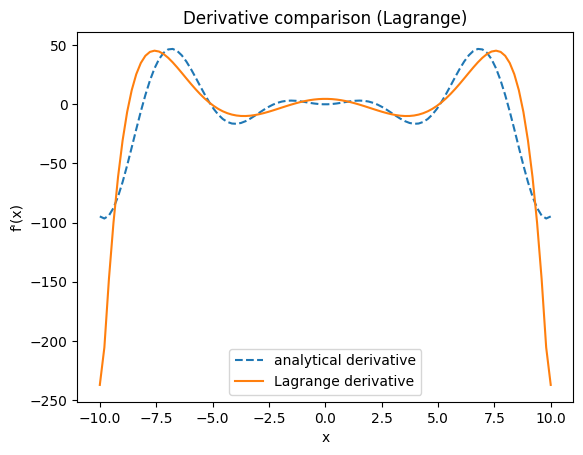

In [ ]:
def Lnj(x,n,j,xdata):
    ret = 1
    for k in range(0, len(xdata)):
        if (k != j):
            ret *= (x - xdata[k]) / (xdata[j] - xdata[k])
    return ret


def f_poly_int(x, xdata, fdata):
    ret = 0
    n = len(xdata) - 1
    for j in range(0, n+1):
        ret += fdata[j] * Lnj(x,n,j,xdata)
    return ret

xpoly = np.linspace(-10,10,100)
fpoly = [f_poly_int(xin,xdat,fdat) for xin in xpoly]
fpoly_dense = np.array([f_poly_int(xin, xdat, fdat) for xin in xref])

plt.title("Polynomial interpolation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(xdat, fdat, 'or')
plt.plot(xpoly,fpoly,label='polynomial interpolation')
plt.plot(xref,fref,'--',label='true function')
plt.legend()
plt.show()

plt.figure()
plt.title("Lagrange interpolation error")
plt.xlabel("x")
plt.ylabel("f(x) - interpolant(x)")
plt.plot(xref, fref - fpoly_dense)
plt.show()

# Derivative on dense grid
dx_ref = xref[1] - xref[0]
f_deriv_lagrange = np.gradient(fpoly_dense, dx_ref)
f_deriv_true = 2*xref*np.sin(xref) + xref**2 * np.cos(xref)

plt.figure()
plt.title("Derivative comparison (Lagrange)")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.plot(xref, f_deriv_true, '--', label='analytical derivative')
plt.plot(xref, f_deriv_lagrange, label='Lagrange derivative')
plt.legend()
plt.show()

Problem 5:
Compare spline, linear, and Lagrange methods in terms of:
- how well they reproduce the function
- how well they reproduce the derivative
- how computationally expensive we expect them to be
- how can spline method be improved?

Answer 5:

Linear interpolation is the least accurate because it uses straight lines between points and cannot capture curvature well. Lagrange interpolation is more accurate for smooth functions since it uses a global polynomial that passes through all points, but it can develop oscillations, especially with many nodes. Cubic spline interpolation is the most accurate overall because it uses piecewise polynomials that fit locally and avoid oscillations while remaining smooth.

For derivatives, linear interpolation performs poorly because the derivative is discontinuous at each node. Lagrange interpolation produces a smooth derivative, but it can be unstable and inaccurate near boundaries. Cubic splines perform best because they ensure continuous first and second derivatives, giving a more realistic derivative.

In terms of computational cost, linear interpolation is the cheapest and fastest to evaluate. Lagrange interpolation is the most expensive because it requires evaluating a global polynomial. Spline interpolation has a moderate setup cost since it requires solving a system once, but evaluation afterward is fast.

Spline methods can be improved by using cubic splines, applying clamped boundary conditions if endpoint derivatives are known, and adding more nodes or using adaptive spacing in regions where the function changes rapidly.

Problem 6: Integration
- Integrate the original and (one of the) interpolated functions
- Compare the answers

Exact integral:  0.000000
Spline integral: -0.000000
Difference:      2.84e-14


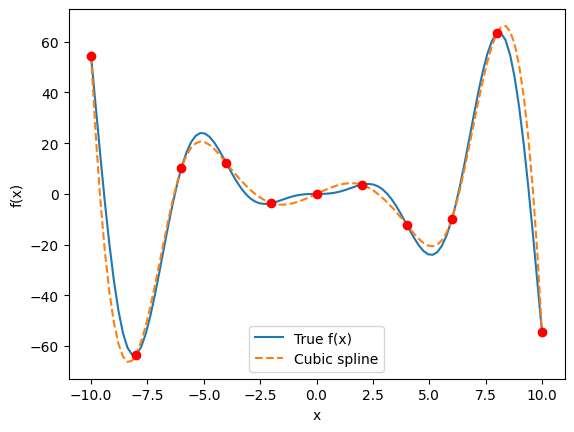

In [ ]:
def f(x):
    return x**2 * np.sin(x)

a, b = -10, 10
xdat = np.linspace(a, b, 11)
fdat = f(xdat)

spline = CubicSpline(xdat, fdat)
I_exact, _ = quad(f, a, b)
I_spline = spline.antiderivative()(b) - spline.antiderivative()(a)

print(f"Exact integral:  {I_exact:.6f}")
print(f"Spline integral: {I_spline:.6f}")
print(f"Difference:      {abs(I_exact - I_spline):.2e}")

xplot = np.linspace(a, b, 100)
plt.plot(xplot, f(xplot), label='True f(x)')
plt.plot(xplot, spline(xplot), '--', label='Cubic spline')
plt.plot(xdat, fdat, 'or')
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend()
plt.show()


Problem 7. Finding  roots:
- Find the root of the equation y = (2 * x + 3) * np.exp(-x) + np.log(x)-1.7 on the interval [0.1, 10]
- Do you expect there will be roots for x > 10? Why?

In [ ]:
def f(x):
    return (2 * x + 3) * np.exp(-x) + np.log(x) - 1.7

x_scan = np.linspace(0.1, 10, 100)
f_scan = f(x_scan)

roots = []
for i in range(len(f_scan) - 1):
    if f_scan[i] * f_scan[i+1] < 0:
        root = brentq(f, x_scan[i], x_scan[i+1])
        roots.append(root)

print(f"Found {len(roots)} root(s) on [0.1, 10]:")
for r in roots:
    print(f"  x = {r:.6f}")

Found 3 root(s) on [0.1, 10]:
  x = 0.461982
  x = 1.699085
  x = 5.023539


Answer 7:

There wont be roots for x>10 because as x approaches infinity, the exponential part of the function goes to zero, so the function becomes logarithmic. For x values greater than 10, the function will be positive which means that it wont cross 0 and that there will be no roots.


Note that for the subsequent 3 problems the answers can be correct and non-unique. So the important thing is to explain your logic.

Problem 8. Consider a ternary phase diagram of the system AxByC1-x-y as a function of (x,y,T,P), where T is temperature and P is pressure
- What is the dimensionality of the parameter space?
- Is the parameter space differentiable?
- Choose some function over this parameter space - it can be indicator function indicating the presence of some phase, or weight fraction of some phase, oe even mechanical or electric properties of th esystem
- Is this function continuous?
- Is this function differentiable?
- Can this function be interpolated, if we have measurements at certain points?
- Can this function be integrated?

Answer 8:

Dimensionality: The parameter space uses (x, y, T, P). Because the composition is constrained (x >= 0, y >= 0, x + y <= 1), the allowed region is still 4D, but with boundaries in the (x, y) part. So it is 4-dimensional with a restricted domain.

Differentiability of the parameter space: The interior (x > 0, y > 0, x + y < 1) behaves like ordinary R^4 and is differentiable. On the edges/corners of the composition triangle, the space has boundaries, so you lose full two-sided differentiability there (you can still talk about one-sided or tangent directions).

Choose a function: Let f(x, y, T, P) = weight fraction of phase alpha at equilibrium.

Is f continuous? Piecewise. Inside a single-phase region, f is constant (0 or 1) and continuous. Inside a two-phase region, f varies continuously. Across phase boundaries, f may stay continuous but usually develops sharp kinks.

Is f differentiable? Not globally. It is differentiable within a single-phase region and often within a two-phase region, but it is usually not differentiable on phase boundaries and around multi-phase intersections.

Can f be interpolated from measurements? Yes, but it's tricky near phase boundaries. Smooth global interpolants tend to smear sharp transitions and can give nonphysical results (negative fractions or > 1). Piecewise interpolation, triangulation in composition space, or interpolating a smoother underlying model is usually better.

Can f be integrated? Yes. Since f is bounded (between 0 and 1), it is integrable over the domain. Discontinuities on phase boundaries do not prevent integration because those boundaries occupy lower-dimensional sets compared to the full 4D space.



Problem 9. Consider charging of the battery, where charging is induced by applying bias over time, V(t).
- What is the dimensionality of the parameter space?
- Is the parameter space differentiable?
- Choose some function over this parameter space - it can be state of charge after charging or state of health. Or probability of thermal runaway.
- Is this function continuous?
- Is this function differentiable?
- Can this function be interpolated, if we have measurements at certain points?
- Can this function be integrated?

Answer 9:

Dimensionality: The input is the whole waveform V(t). That makes the parameter space effectively infinite-dimensional (a function space). If you restrict V(t) to a finite parameterization (for example, piecewise-constant values over N time bins, or a few spline control points), then it becomes N-dimensional (or “number of control parameters” dimensional).

Differentiability of the parameter space: As a function space it can be treated as differentiable under the right math setup, but in practice you usually work with a finite parameterization where it is just ordinary differentiable R^N.

Choose a function: Let f[V(t)] = state of charge (SOC) at the end of charging, or probability of thermal runaway.

Continuity: Often approximately continuous with respect to small changes in V(t), but it can have sharp transitions (for example when hitting voltage/current limits, triggering protection logic, phase changes, lithium plating onset, or thermal runaway thresholds), so it may not be continuous everywhere.

Differentiability: Typically differentiable away from regime changes, but not differentiable at switching events (controller mode changes like CC-to-CV, saturations, hysteresis, thresholds).

Interpolation: Yes, if you represent V(t) with finite parameters. You can interpolate/regress f over that parameter space, but you need enough coverage and you must handle thresholds (piecewise models work better near discontinuities).

Integration: Yes. You can integrate f over a distribution of charging protocols (expected SOC/expected risk), or integrate quantities derived from V(t) like energy input (integral of V(t) I(t) dt) or total charge (integral of I(t) dt).

Problem 10. Consider the chemical space of small molecules, https://en.wikipedia.org/wiki/Chemical_space .
- What is the dimensionality of the parameter space?
- Is the parameter space differentiable?
- Choose some function over this parameter space - it can be anything from molecular weight to enthalpy of formation, HOMO-LUMO gap, etc/
- Is this function continuous?
- Is this function differentiable?
- Can this function be interpolated, if we have measurements at certain points?
- Can this function be integrated?

Answer 10:

Dimensionality: Chemical space consists of all possible small molecules. As a set of discrete molecular structures, it does not have a fixed finite dimension. However, if molecules are represented using d descriptors (such as molecular weight, atom counts, or learned embeddings), then the parameter space can be treated as d-dimensional.

Differentiability of the parameter space: The true chemical space is discrete, so it is not differentiable. If molecules are mapped into a continuous descriptor or embedding space, then that representation is differentiable because it behaves like ordinary vector space.

Choose some funstion: Let f(molecule) = molecular weight, enthalpy of formation, etc.

Is the function continuous: On the discrete set of molecules, the function is not truly continuous because small structural changes can cause sudden jumps in properties. In a continuous descriptor space, a fitted surrogate model of the function can be continuous.

Is the function differentiable: On discrete molecules, it is not differentiable.

Can it be interpolated: Yes, if molecules are represented in a descriptor or embedding space. Interpolation methods can estimate properties of new molecules based on nearby known molecules.

Can it be integrated: Yes. Over discrete molecules, integration becomes a sum or average over a set of molecules. In a continuous descriptor space, standard integration methods can be used on surrogate functions.